# Stopping power vs projectile localisation — **σ sweep**

$$S \;=\; \frac{E_{\rm total}(t_{\rm final}) - E_{\rm GS}}{L_{{\rm slab},z}}
\qquad L_{{\rm slab},z} = 25\ \mathrm{Bohr}$$

The localised-jellium **deposit** definition, evaluated on three wavepacket
campaigns that differ in exactly one parameter: the wavepacket width σ_WP.
Everything else — ground state, dx = 0.40, launch z = −24, the two 12.5 Bohr CAPs
with η = −1, dt = 0.04, step counts, and the four velocities — is held fixed.

## Why σ is the interesting axis

σ_WP sets how fast the packet stops being a localised object. A free Gaussian's
density width grows as

$$s(t) \;=\; \sqrt{\tfrac{\sigma^2}{2} + \tfrac{t^2}{2\sigma^2}},$$

so the asymptotic spreading rate is $1/(\sqrt2\,\sigma)$: **1.414** Bohr/a.u. at
σ = 0.5, **0.354** at σ = 2, **0.236** at σ = 3. Launched at z = −24 with the slab
face at −12.5, the σ = 0.5 packet is already 4.7–8.1 Bohr wide when it arrives and
15–26 Bohr wide when it leaves — wider than the 25 Bohr slab. The σ = 2 and 3
packets arrive at 1.8–2.5 Bohr and leave at 3.2–6.6 Bohr.

σ also fixes the momentum width, $\sigma_p = 1/(\sqrt2\,\sigma)$, hence the
zero-point kinetic content $T_1 - T_2 = 3/(4\sigma^2)$ = **81.6 / 5.10 / 2.27 eV**
for σ = 0.5 / 2 / 3. A broad packet is closer to a plane wave of definite momentum,
which is the limit in which "stopping power at velocity v" is even well posed.

## What this estimator does and does not measure

It is the same formula the classical benchmark uses, but the two are **not** the
same measurement, and the difference matters more here than anywhere else in the
campaign. Classically the projectile is an external perturbation, never in the
electronic ledger, so `plateau − E_GS` is purely the slab's energy gain. Here the
wavepacket **is** part of the system and the CAP removes it, so
`E_total(t_final) − E_GS` is *what is left in the box* once everything the CAP
absorbed has been subtracted: a **lower bound** on the deposit.

Both the raw and the norm-corrected ledgers are plotted. The correction removes
INQ's norm-divided kinetic term (`energy.hpp`), which otherwise inflates the
residual as the CAP eats the packet — on the raw ledger at σ = 0.5 this estimator
comes out velocity-*independent* at ~2.44 eV/Bohr, which no stopping power can be.


In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "/rds/user/skcb2/hpc-work/tddft/inq-tddft-research/ResearchProject/systems/localised_jellium/hypotheses/wp_highdensity_sv")
import wp_hd_stopping as W

rows = []
for s in W.SIGMAS:
    if not W.has_campaign(s):
        print(f"sigma={s}: no results on disk — skipped")
        continue
    W.set_campaign(s)
    for v in W.VELOCITIES:
        try:
            dep = W.deposit_stopping(v, sigma=s)
        except (FileNotFoundError, KeyError, IndexError) as e:
            print(f"sigma={s} v={v}: MISSING ({type(e).__name__})"); continue
        rows.append(dict(sigma=s, v=v,
                         s0_bohr=s/np.sqrt(2),
                         s_at_entry=float(W.sigma_d((abs(W.LAUNCH_Z)-W.SLAB_HALF)/v, s)),
                         s_at_exit=float(W.sigma_d((abs(W.LAUNCH_Z)+W.SLAB_HALF)/v, s)),
                         **dep))
d_all = pd.DataFrame(rows)

# COMPLETENESS GATE. A run that is still propagating (or was killed) yields a
# mid-flight E_total that looks like a perfectly plausible deposit but is not one:
# the packet has not deposited and the CAP has not removed it. Incomplete points
# are reported, then EXCLUDED from the figure.
incomplete = d_all[~d_all.complete]
if len(incomplete):
    print("EXCLUDED — run not finished:")
    display(incomplete[["sigma", "v", "steps_done", "steps_target",
                        "t_final_au", "norm_final", "S_deposit_corrected"]].round(3))
d = d_all[d_all.complete].copy()
print(f"{len(d)} of {len(d_all)} points complete")
display(d.round(4))
d_all.to_csv("sigma_sweep_S_deposit.csv", index=False)
print("wrote sigma_sweep_S_deposit.csv (all points, with a `complete` column)")

12 of 12 points complete


,sigma,v,s0_bohr,s_at_entry,s_at_exit,E_deposit_raw_eV,E_deposit_corrected_eV,S_deposit_raw,S_deposit_corrected,norm_final,t_final_au,steps_done,steps_target,complete
0,0.5,2.0,0.3536,8.1394,25.8118,61.7822,5.9788,2.4713,0.2392,0.0638,144.92,3623,3623,True
1,0.5,2.5,0.3536,6.5150,20.6505,61.1864,5.0042,2.4475,0.2002,0.0462,115.92,2898,2898,True
2,0.5,3.0,0.3536,5.4327,17.2099,61.1573,4.1831,2.4463,0.1673,0.0321,96.60,2415,2415,True
3,0.5,3.5,0.3536,4.6601,14.7525,60.8377,3.2713,2.4335,0.1309,0.0182,82.80,2070,2070,True
4,2.0,2.0,1.4142,2.4765,6.6055,17.5456,8.8814,0.7018,0.3553,0.0000,144.92,3623,3623,True
5,2.0,2.5,1.4142,2.1552,5.3521,18.3886,8.9793,0.7355,0.3592,0.0000,115.92,2898,2898,True
6,2.0,3.0,1.4142,1.9588,4.5281,20.1649,7.2900,0.8066,0.2916,0.0000,96.60,2415,2415,True
7,2.0,3.5,1.4142,1.8302,3.9490,95.8077,5.4621,3.8323,0.2185,0.0000,82.80,2070,2070,True
8,3.0,2.0,2.1213,2.5173,4.7962,17.1803,10.7928,0.6872,0.4317,0.0000,144.92,3623,3623,True
9,3.0,2.5,2.1213,2.3823,4.0426,17.8975,10.0286,0.7159,0.4011,0.0000,115.92,2898,2898,True


wrote sigma_sweep_S_deposit.csv (all points, with a `complete` column)


## The figure

Solid = norm-corrected ledger (the physical trace). Dotted = raw INQ ledger, kept
visible because its flatness is the diagnostic that motivated the correction.

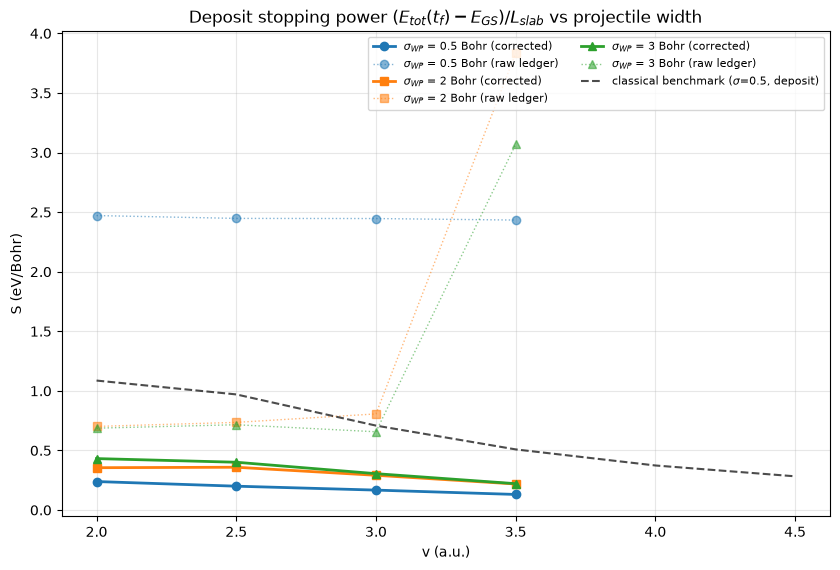

wrote sigma_sweep_S_deposit.png


In [2]:
MK = {0.5: ("C0", "o"), 2.0: ("C1", "s"), 3.0: ("C2", "^")}

fig, ax = plt.subplots(figsize=(8.5, 5.8))
for s, g in d.groupby("sigma"):
    c, m = MK.get(s, ("C7", "x"))
    g = g.sort_values("v")
    ax.plot(g.v, g.S_deposit_corrected, color=c, marker=m, lw=2,
            label=f"$\\sigma_{{WP}}$ = {s:g} Bohr (corrected)")
    ax.plot(g.v, g.S_deposit_raw, color=c, marker=m, lw=1, ls=":", alpha=.55,
            label=f"$\\sigma_{{WP}}$ = {s:g} Bohr (raw ledger)")

try:
    cl = W.classical_reference()
    ax.plot(cl.v, cl.S_eV_per_Bohr, "k--", lw=1.5, alpha=.7,
            label="classical benchmark ($\\sigma$=0.5, deposit)")
except Exception as e:
    print("classical reference unavailable:", e)

ax.set(xlabel="v (a.u.)", ylabel="S (eV/Bohr)",
       title="Deposit stopping power $(E_{tot}(t_f)-E_{GS})/L_{slab}$ vs projectile width")
ax.grid(alpha=.3); ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig("sigma_sweep_S_deposit.png", dpi=140); plt.show()
print("wrote sigma_sweep_S_deposit.png")

## Companion: how wide the packet actually is when it does the physics

The deposit curve above is only interpretable alongside this — it is the reason
the σ campaigns were run. `s_at_entry` is the density standard deviation when the
centroid reaches the slab face at z = −12.5; `s_at_exit` when it reaches +12.5.

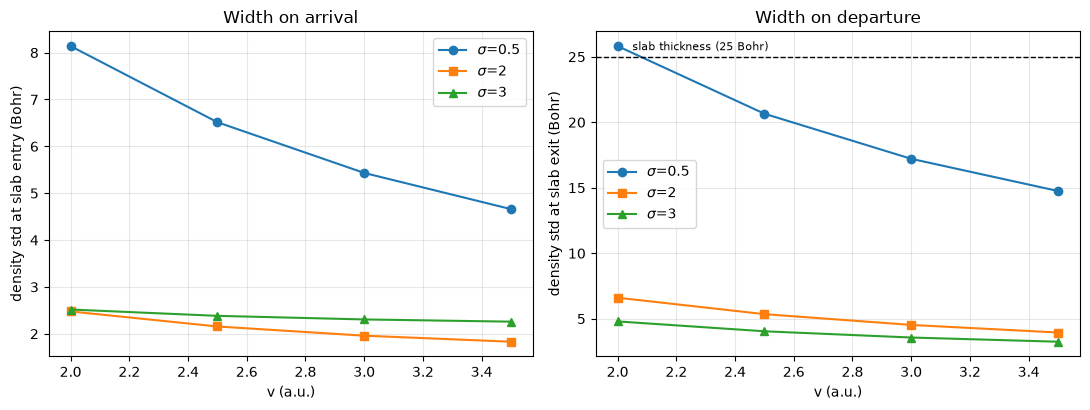

wrote sigma_sweep_widths.png


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for s, g in d.groupby("sigma"):
    c, m = MK.get(s, ("C7", "x"))
    g = g.sort_values("v")
    ax[0].plot(g.v, g.s_at_entry, color=c, marker=m, label=f"$\\sigma$={s:g}")
    ax[1].plot(g.v, g.s_at_exit, color=c, marker=m, label=f"$\\sigma$={s:g}")
ax[0].set(xlabel="v (a.u.)", ylabel="density std at slab entry (Bohr)",
          title="Width on arrival")
ax[1].set(xlabel="v (a.u.)", ylabel="density std at slab exit (Bohr)",
          title="Width on departure")
ax[1].axhline(2*W.SLAB_HALF, ls="--", c="k", lw=1)
ax[1].annotate("slab thickness (25 Bohr)", (2.05, 2*W.SLAB_HALF*1.02), fontsize=8)
for a in ax: a.grid(alpha=.3); a.legend()
fig.tight_layout(); fig.savefig("sigma_sweep_widths.png", dpi=140); plt.show()
print("wrote sigma_sweep_widths.png")

## Reading this honestly — three caveats

1. **The σ = 3 packet starts inside the −z CAP.** Launch is z = −24 and the CAP
   inner edge is z = −30, so the 6 Bohr clearance is 4.2 density-std at σ = 2 but
   only 2.8 at σ = 3, where ≈0.23 % of the packet is absorbed immediately. That is
   a one-off norm loss, not a stopping effect; it is reproduced by the matching
   vacuum control (`vac_s3p0_*`) and should be checked there before any σ = 3 vs
   σ = 2 difference is called physics.
2. **This is a lower bound, and the bound is σ-dependent.** How much of the packet
   the CAP has removed by t_final differs between campaigns, so part of any σ
   trend is CAP bookkeeping rather than deposition. The vacuum controls at each σ
   are what separate the two.
3. **No classical twin exists at σ = 2 or 3.** The classical benchmark was run at
   σ_pot = 0.354 = 0.5/√2 only. The dashed classical curve is orientation, not a
   like-for-like comparison, for the two wider campaigns.

A deposit measure genuinely comparable to the classical one would be the bath's
own internal energy change, ΔE_SS + ΔE_SB from the pairwise ledger — available
every step in `interactions.csv` for all three campaigns, and not yet built.
